# Example for Invariance through "weight sharing"

The kernel permutation-invariant kernel is defined as
$$k(\boldsymbol{x}, \boldsymbol{x}^\prime) = \sum_{i=1}^{D}\sum_{j=1}^{D} k_{b}(x_i, x_j).$$

The weighted kernel is defined as
$$k(\boldsymbol{x}, \boldsymbol{x}^\prime) = \sum_{i=1}^{D}\sum_{j=1}^{D} w_i w_j k_{b}(x_i, x_j).$$

Let $G$ be the group acting on the inputs (all possible permutations).
Reversing the input is the action of group $H \subset G$.

Let $\boldsymbol{\phi}: \mathbb{R}^{D}  \rightarrow Fix(H, \mathbb{R}^{D})$ be a map of the weights $\boldsymbol{w} = (w_1, \dots, w_D)$ into the set of fixed points under the action of group $H$ which is defined as
$$\boldsymbol{\phi}(\boldsymbol{w}) = \frac{1}{\lvert H \rvert} \sum_{h \in H} \lambda(h) \boldsymbol{w}$$
where $\lambda$ is the linear representation of $H$, i.e. maps the group elements to permutation matrices.

The code shows how constraining the weights to the set of fixed points under the action of group $H$ leads to an $H \times H$-equivariant kernel map which results in an $H$-invariant kernel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(100)

In [2]:
def k_rbf(x1, x2, sigma=1., lengthscales=1.):
    '''
    RBF kernel used as base kernel.
    '''
    x1_scaled = np.divide(x1, lengthscales) 
    x2_scaled = np.divide(x2, lengthscales) 
    x1s = np.sum(np.square(x1_scaled), axis=-1) 
    x2s = np.sum(np.square(x2_scaled), axis=-1) 
    dist_squared = -2 * np.tensordot(x1_scaled, x2_scaled, [[-1], [-1]]) 
    dist_squared += np.add(np.reshape(x1s, [-1, 1]), np.reshape(x2s, [1, -1])) 
    return np.square(sigma) * np.exp(-0.5 * dist_squared) 


class PermutationKernel:
    '''
    Kernel with permutation-equivariant intermediate kernel map.
    Psi computes and returns the intermediate kernel map.
    Psi_prime returns the weighted kernel map.
    Summing over the elements in the kernel map gives the evaluation of the kernel.

    Reversing an input forms a group H of transformations with group order two.
    Method phi maps the weights into the space of fixed points of the group action ("weight sharing").
    Psi_prime_equivarweighted returns the corresponding HxH-equivariant weighted kernel map.

    K_invar computes the fully permutation-invariant kernel.
    K_weighted computes the non-invariant weighted version of the kernel.
    K_weightedinvar computes the H-invariant version of the kernel.
    '''
    def __init__(self, base_kernel, D, weights=None):
        self.base_kernel = base_kernel
        self.D = D
        self.weights = weights
        self.grouporder = 2 # order of group H

    def phi(self, w):
        '''
        Map weights into set of fixed points with "Average-over-orbit"-method.
        '''
        return (w + np.flip(w)) / self.grouporder

    def get_W(self, w):
        W = np.reshape(w, [self.D, 1]) * np.reshape(w, [1, self.D])
        return W

    def get_W_fixedpoints(self, w):
        phi_w = self.phi(w)
        W = np.reshape(phi_w, [self.D, 1]) * np.reshape(phi_w, [1, self.D])
        return W

    def Psi(self, x, x_prime):
        X = np.reshape(x, [self.D, 1])
        X_prime = np.reshape(x_prime, [self.D, 1])
        return self.base_kernel(X, X_prime)

    def Psi_prime(self, x, x_prime):
        W = self.get_W(self.weights)
        return W * self.Psi(x, x_prime)

    def Psi_prime_equivarweighted(self, x, x_prime):
        W = self.get_W_fixedpoints(self.weights)
        return W * self.Psi(x, x_prime)

    def K_invar(self, x, x_prime):
        return (np.sum(self.Psi(x, x_prime))) #/ self.D**2

    def K_weighted(self, x, x_prime):
        return (np.sum(self.Psi_prime(x, x_prime))) #/ self.D**2

    def K_weightedinvar(self, x, x_prime):
        return (np.sum(self.Psi_prime_equivarweighted(x, x_prime))) #/ self.D**2
        

In [3]:
# initialisation of kernel

D = 5
x = np.random.rand(D) * 3
x_prime = np.random.rand(D) * 3
weights = np.round((np.random.rand(D) - 0.5) * 4, 3)

kernel = PermutationKernel(base_kernel=k_rbf, D=D, weights=weights)

## Weights, weight matrix with and without constraint

In [4]:
print(kernel.weights) # raw weights
print(kernel.phi(kernel.weights)) # constrained weights

[ 1.565 -1.163 -1.259 -1.566 -1.121]
[ 0.222  -1.3645 -1.259  -1.3645  0.222 ]


In [5]:
W = kernel.get_W(kernel.weights)
W_constrained = kernel.get_W_fixedpoints(kernel.weights)

In [6]:
print(W) # weight matrix
print()
print(W_constrained) # weight matrix with constrained weights

[[ 2.449225 -1.820095 -1.970335 -2.45079  -1.754365]
 [-1.820095  1.352569  1.464217  1.821258  1.303723]
 [-1.970335  1.464217  1.585081  1.971594  1.411339]
 [-2.45079   1.821258  1.971594  2.452356  1.755486]
 [-1.754365  1.303723  1.411339  1.755486  1.256641]]

[[ 0.049284   -0.302919   -0.279498   -0.302919    0.049284  ]
 [-0.302919    1.86186025  1.7179055   1.86186025 -0.302919  ]
 [-0.279498    1.7179055   1.585081    1.7179055  -0.279498  ]
 [-0.302919    1.86186025  1.7179055   1.86186025 -0.302919  ]
 [ 0.049284   -0.302919   -0.279498   -0.302919    0.049284  ]]


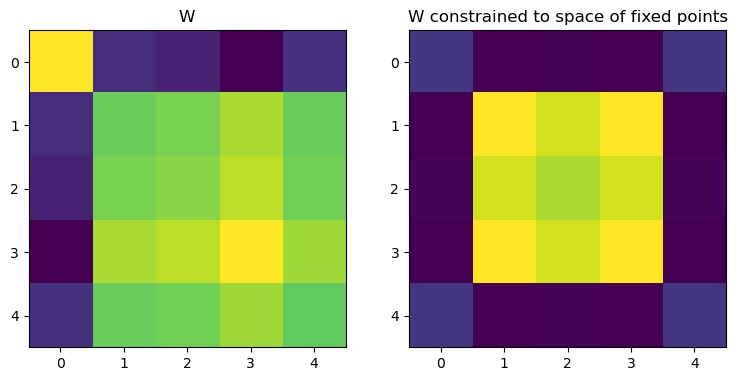

In [7]:
fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(1,2,1)
ax.imshow(W)
ax.set_title("W")

ax = fig.add_subplot(1,2,2)
ax.imshow(W_constrained)
ax.set_title("W constrained to space of fixed points")

plt.show()
plt.close()

## Weight-free kernel: equivariant kernel map, invariant kernel

In [8]:
psi1 = kernel.Psi(x, x_prime)
psi2 = kernel.Psi(np.flip(x), x_prime) # left action
psi3 = kernel.Psi(x, np.flip(x_prime)) # right action
psi4 = kernel.Psi(np.flip(x), np.flip(x_prime)) # left and right action combined, action of product group

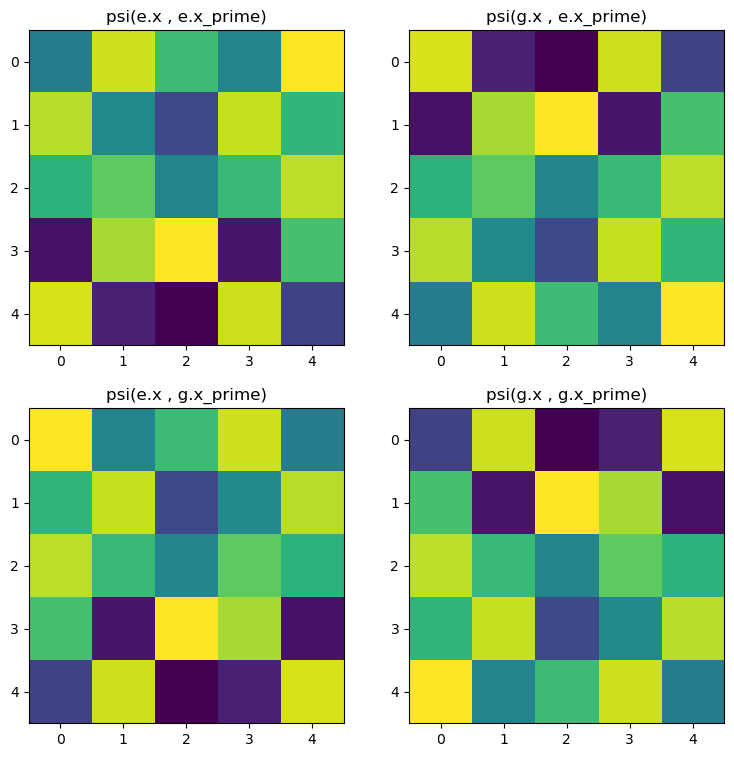

In [9]:
fig = plt.figure(figsize=(9, 9))

ax = fig.add_subplot(2,2,1)
ax.imshow(psi1)
ax.set_title("psi(e.x , e.x_prime)")

ax = fig.add_subplot(2,2,2)
ax.imshow(psi2)
ax.set_title("psi(g.x , e.x_prime)")

ax = fig.add_subplot(2,2,3)
ax.imshow(psi3)
ax.set_title("psi(e.x , g.x_prime)")

ax = fig.add_subplot(2,2,4)
ax.imshow(psi4)
ax.set_title("psi(g.x , g.x_prime)")

plt.show()
plt.close()

In [10]:
print(kernel.K_invar(x, x_prime))

print(kernel.K_invar(np.flip(x), x_prime))

print(kernel.K_invar(x, np.flip(x_prime)))

print(kernel.K_invar(np.flip(x), np.flip(x_prime)))

print("some random permutations of inputs:")
print(kernel.K_invar(np.random.permutation(x), np.random.permutation(x_prime))) # random permutation of inputs

15.360096951813297
15.360096951813297
15.360096951813297
15.360096951813299
some random permutations of inputs:
15.360096951813297


## Weighted kernel map, weighted kernel (not in general invariant)

In [11]:
#kernel.Psi_prime(x, x_prime)

In [12]:
psi1 = kernel.Psi_prime(x, x_prime)
psi2 = kernel.Psi_prime(np.flip(x), x_prime) # left action
psi3 = kernel.Psi_prime(x, np.flip(x_prime)) # right action
psi4 = kernel.Psi_prime(np.flip(x), np.flip(x_prime)) # left and right action combined, action of product group

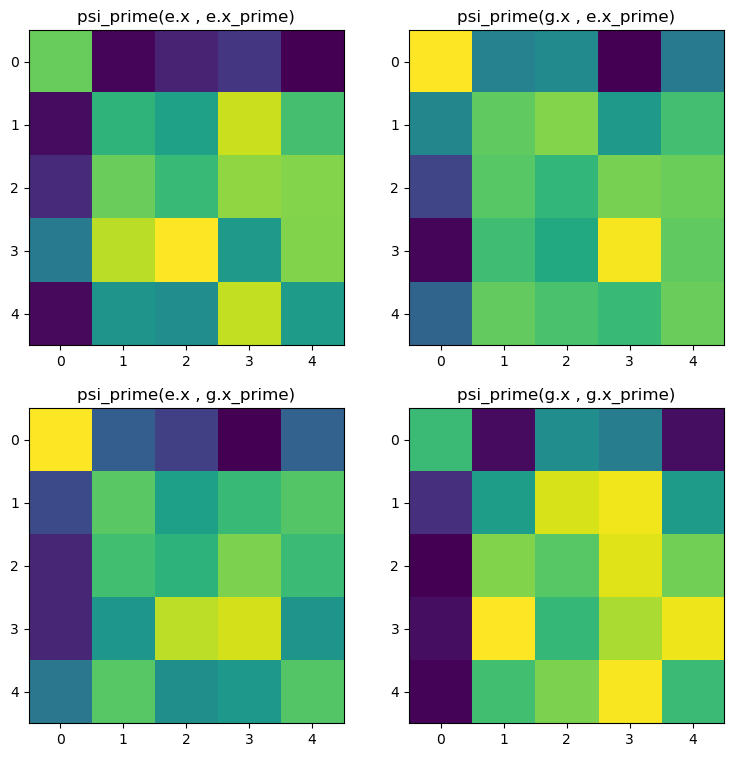

In [13]:
fig = plt.figure(figsize=(9, 9))

ax = fig.add_subplot(2,2,1)
ax.imshow(psi1)
ax.set_title("psi_prime(e.x , e.x_prime)")

ax = fig.add_subplot(2,2,2)
ax.imshow(psi2)
ax.set_title("psi_prime(g.x , e.x_prime)")

ax = fig.add_subplot(2,2,3)
ax.imshow(psi3)
ax.set_title("psi_prime(e.x , g.x_prime)")

ax = fig.add_subplot(2,2,4)
ax.imshow(psi4)
ax.set_title("psi_prime(g.x , g.x_prime)")

plt.show()
plt.close()

In [14]:
print(kernel.K_weighted(x, x_prime))

print(kernel.K_weighted(np.flip(x), x_prime))

print(kernel.K_weighted(x, np.flip(x_prime)))

print(kernel.K_weighted(np.flip(x), np.flip(x_prime)))

print(kernel.K_weighted(np.random.permutation(x), np.random.permutation(x_prime))) # random permutation of inputs

5.656635518741117
12.24563543151292
7.019514635255
6.622094429458957
5.284065600428503


## Weighted equivariant kernel maps, H-invariant kernel (constrained weights)

In [15]:
psi1 = kernel.Psi_prime_equivarweighted(x, x_prime)
psi2 = kernel.Psi_prime_equivarweighted(np.flip(x), x_prime) # left action
psi3 = kernel.Psi_prime_equivarweighted(x, np.flip(x_prime)) # right action
psi4 = kernel.Psi_prime_equivarweighted(np.flip(x), np.flip(x_prime)) # left and right action combined, action of product group

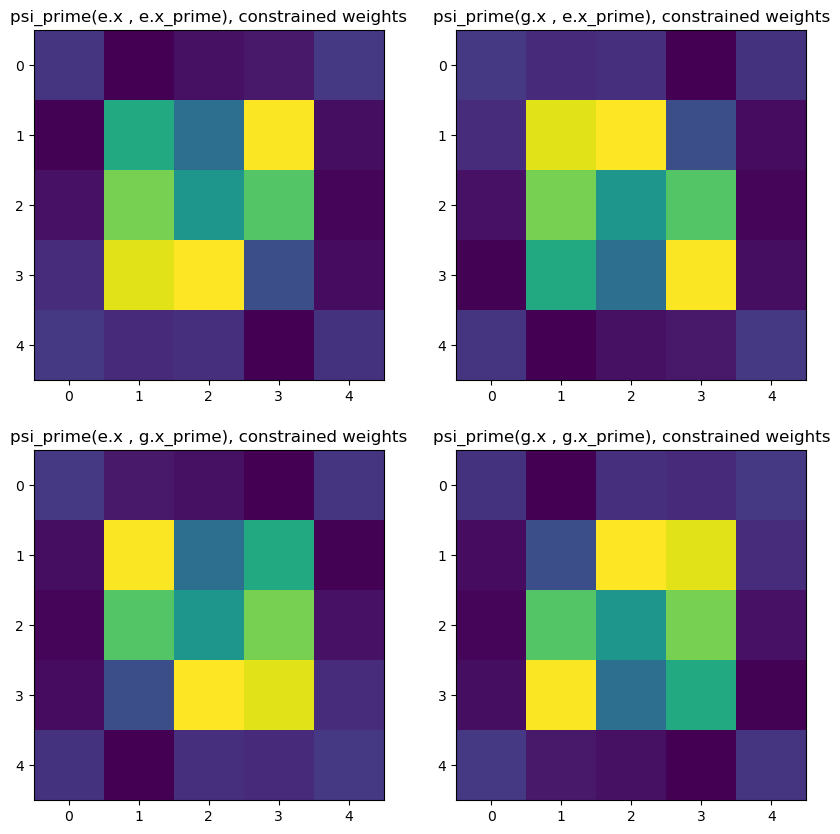

In [16]:
fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(2,2,1)
ax.imshow(psi1)
ax.set_title("psi_prime(e.x , e.x_prime), constrained weights")

ax = fig.add_subplot(2,2,2)
ax.imshow(psi2)
ax.set_title("psi_prime(g.x , e.x_prime), constrained weights")

ax = fig.add_subplot(2,2,3)
ax.imshow(psi3)
ax.set_title("psi_prime(e.x , g.x_prime), constrained weights")

ax = fig.add_subplot(2,2,4)
ax.imshow(psi4)
ax.set_title("psi_prime(g.x , g.x_prime), constrained weights")

plt.show()
plt.close()

In [17]:
print(kernel.K_weightedinvar(x, x_prime))

print(kernel.K_weightedinvar(np.flip(x), x_prime))

print(kernel.K_weightedinvar(x, np.flip(x_prime)))

print(kernel.K_weightedinvar(np.flip(x), np.flip(x_prime)))

print("other permutations than action of subgroup H:")
print(kernel.K_weightedinvar(np.random.permutation(x), np.random.permutation(x_prime))) # random permutation of inputs

7.885970003741997
7.885970003741998
7.885970003741997
7.885970003741998
other permutations than action of subgroup H:
8.720336406448041
